# ch309 — Activation Functions Deep Dive

## 1. Why activation functions exist

Without nonlinearities, a depth-$L$ network collapses to a single matrix multiplication:
$$W^{[L]} \cdots W^{[2]} W^{[1]} x = W_{\text{eff}} x$$

Activation functions are the source of expressive power *(introduced in ch064–ch065)*.
This chapter surveys the full family and analyses each choice's effect on gradient flow.

---

## 2. The family

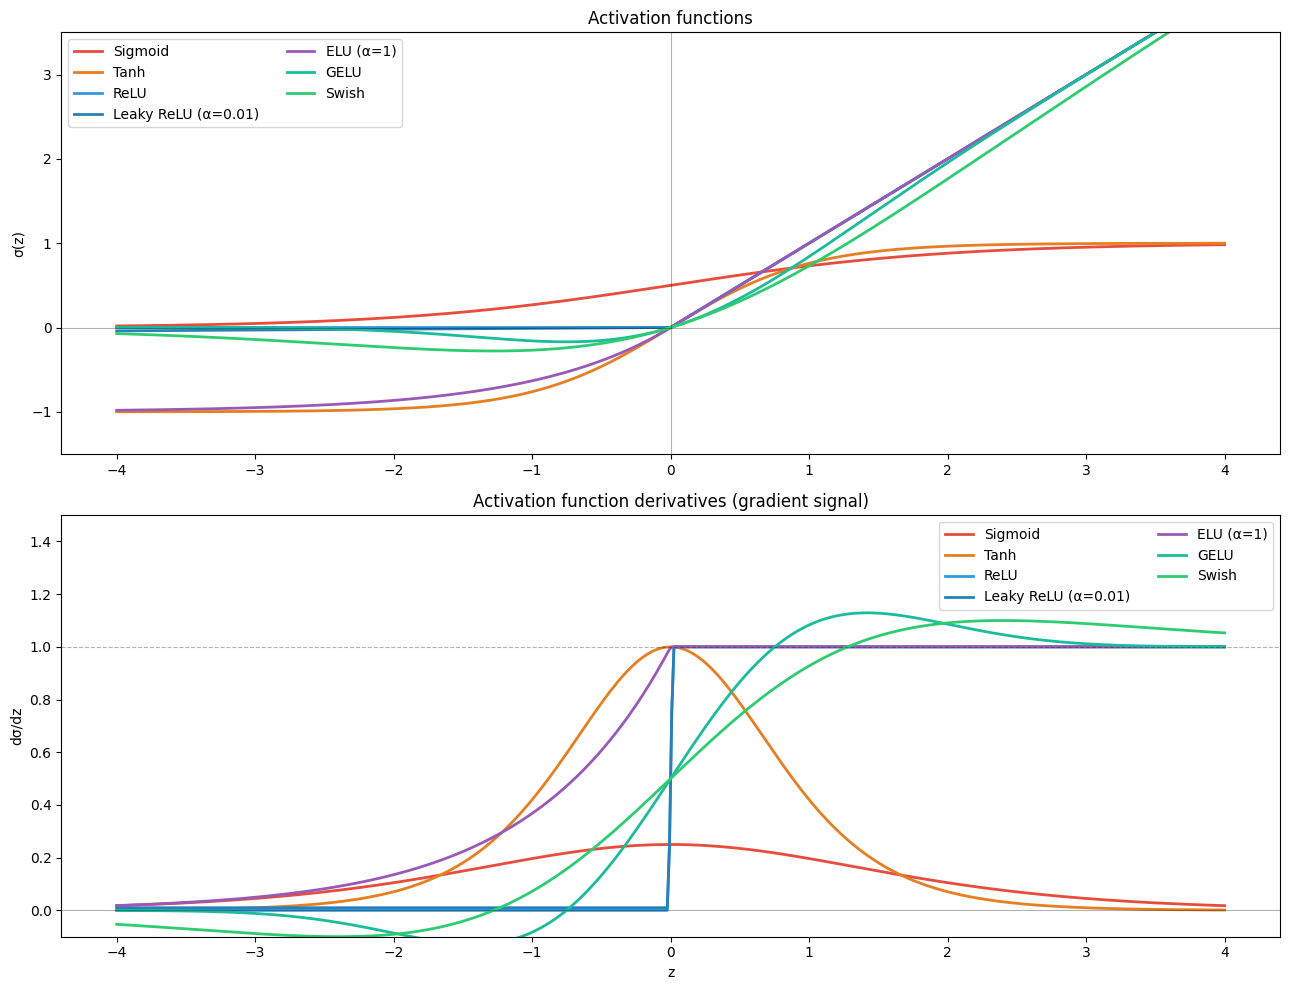

Key observations:
  Sigmoid/Tanh: derivative peaks at ~0.25 / 1.0; saturates to 0 at extremes → vanishing gradients
  ReLU: derivative is 1 for z>0, 0 for z<0 → dead neuron problem but no saturation
  GELU/Swish: smooth, non-monotone; gradient non-zero even slightly left of 0


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def tanh(z): return np.tanh(z)
def relu(z): return np.maximum(0, z)
def leaky_relu(z, alpha=0.01): return np.where(z > 0, z, alpha * z)
def elu(z, alpha=1.0): return np.where(z > 0, z, alpha * (np.exp(np.clip(z, -500, 0)) - 1))
def gelu(z):
    """Gaussian Error Linear Unit — used in BERT, GPT."""
    return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))
def swish(z): return z * sigmoid(z)
def mish(z): return z * np.tanh(np.log1p(np.exp(np.clip(z, -500, 20))))

acts = [
    (sigmoid, 'Sigmoid', '#e74c3c'),
    (tanh, 'Tanh', '#e67e22'),
    (relu, 'ReLU', '#3498db'),
    (leaky_relu, 'Leaky ReLU (α=0.01)', '#2980b9'),
    (elu, 'ELU (α=1)', '#9b59b6'),
    (gelu, 'GELU', '#1abc9c'),
    (swish, 'Swish', '#2ecc71'),
]

z = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

for fn, name, color in acts:
    axes[0].plot(z, fn(z), label=name, color=color, lw=2)

axes[0].axhline(0, color='black', alpha=0.3, lw=0.8)
axes[0].axvline(0, color='black', alpha=0.3, lw=0.8)
axes[0].set_title('Activation functions')
axes[0].set_ylabel('σ(z)')
axes[0].legend(ncol=2)
axes[0].set_ylim(-1.5, 3.5)

# Numerical derivatives
dz = z[1] - z[0]
for fn, name, color in acts:
    grad = np.gradient(fn(z), dz)
    axes[1].plot(z, grad, label=name, color=color, lw=2)

axes[1].axhline(0, color='black', alpha=0.3, lw=0.8)
axes[1].axhline(1, color='black', alpha=0.3, lw=0.8, linestyle='--')
axes[1].set_title("Activation function derivatives (gradient signal)")
axes[1].set_ylabel("dσ/dz")
axes[1].set_xlabel("z")
axes[1].legend(ncol=2)
axes[1].set_ylim(-0.1, 1.5)

plt.tight_layout()
plt.savefig('ch309_activations.png', dpi=120)
plt.show()

print("Key observations:")
print("  Sigmoid/Tanh: derivative peaks at ~0.25 / 1.0; saturates to 0 at extremes → vanishing gradients")
print("  ReLU: derivative is 1 for z>0, 0 for z<0 → dead neuron problem but no saturation")
print("  GELU/Swish: smooth, non-monotone; gradient non-zero even slightly left of 0")

## 3. Choosing an activation

| Activation | Gradient at saturation | Dead neurons | Recommended use |
|------------|----------------------|--------------|-----------------|
| Sigmoid | ≈0 (saturates) | No | Output layer (binary prob) |
| Tanh | ≈0 (saturates) | No | Legacy; some RNNs |
| ReLU | Exact 0 for z<0 | Yes (dead) | Hidden layers, CNNs |
| Leaky ReLU | α (small) | Very rare | ReLU alternative |
| ELU | Negative mean, smooth | No | Slightly better than ReLU |
| GELU | Smooth near 0 | No | Transformers, BERT, GPT |
| Swish | Smooth, non-monotone | Rare | EfficientNet, modern CNNs |

**Default choice:** ReLU for CNNs and MLPs; GELU for Transformers.

---

## 4. The dead ReLU problem

A ReLU neuron is dead when $z < 0$ for every sample in every batch. Its gradient is
identically zero — it will never recover via gradient descent. This can happen if:
- Learning rate is too large (a bad update pushes weights into the always-negative regime).
- Biases are initialised too negatively.

Fix: Leaky ReLU, ELU, or careful learning rate scheduling.

---

## 5. Activation choice in the output layer

| Output type | Activation | Loss |
|---|---|---|
| Regression | None (linear) | MSE |
| Binary class | Sigmoid | BCE |
| Multiclass | Softmax | Categorical CE |
| Multi-label | Sigmoid (per class) | BCE |

---

## 6. Summary

- Nonlinearity is mandatory; without it depth collapses to a single linear map.
- Sigmoid/Tanh saturate → vanishing gradients. Use them only at output (binary/regression).
- ReLU: simple, fast, but risks dead neurons. Default for hidden layers.
- GELU/Swish: smooth, more expressive, preferred in modern Transformers.
- Derivative shape determines gradient signal; a flat derivative region = dead zone.

---

## 7. Forward and backward references

**Used here:** sigmoid and activation functions *(ch064–ch065)*, derivative *(ch205)*,
vanishing gradients *(ch306)*, initialisation *(ch308)*.

**This will reappear in ch321 — Attention Mechanism**, where the softmax activation
is used to compute attention weights, and in ch322 — Transformers, where GELU is
the standard hidden activation in the feed-forward sublayer.